# Trabalho 1 - Algoritmos para Agrupamento de Dados
### Aluno: Leonardo Scholl Sternberg

# Base de Dados

## Contexto e Estrutura dos dados
Este é um conjunto de dados transacionais que contém todas as transações ocorridas entre 01/12/2010 e 09/12/2011 para uma empresa de varejo online sem loja física, sediada e registrada no Reino Unido. A empresa vende principalmente presentes exclusivos para todas as ocasiões. Muitos dos clientes da empresa são atacadistas.
Dataset: https://www.kaggle.com/datasets/carrie1/ecommerce-data

- **Número de registros**: 541.909 linhas.
- **Colunas principais**:
  - `InvoiceNo`: Número da fatura (string).
  - `StockCode`: Código do produto (string).
  - `Description`: Descrição do produto (string).
  - `Quantity`: Quantidade comprada (inteiro).
  - `InvoiceDate`: Data da fatura (string/datetime).
  - `UnitPrice`: Preço unitário (float).
  - `CustomerID`: ID do cliente (float, com valores ausentes).
  - `Country`: País do cliente (string).

## Carregando dataset

In [1]:
# !/usr/bin/env python3
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Baixar dataset
path = kagglehub.dataset_download("carrie1/ecommerce-data")
df = pd.read_csv(f"{path}/data.csv", encoding='latin1')

print(f"Dataset carregado: {df.shape[0]} linhas e {df.shape[1]} colunas.")

Dataset carregado: 541909 linhas e 8 colunas.


## Análise dos Dados

Para uma compreensão mais profunda dos dados, visualizamos distribuições de variáveis-chave. Isso ajuda a identificar outliers, assimetrias e padrões iniciais antes do pré-processamento. Conseguimos ver:
- Identificação de dados duplicados
- Indeitificação de dados nulos
- Identificação de Ruídos Operacionais (UnitPrice < 0, Quantity < 0)
- Diagnóstico de Assimetria Extrema (Reino Unido dominando a base)

In [2]:
# Ver as primeiras linhas para entender a "cara" dos dados
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [3]:
# Ver tipos de dados e se há valores nulos óbvios
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
None


In [4]:
# Verificar se há linhas duplicadas
print(f"Duplicados: {df.duplicated().sum()}")

Duplicados: 5268


In [5]:
# Criando um resumo da cardinalidade
resumo_unique = pd.DataFrame({
    'Coluna': df.columns,
    'Tipo': df.dtypes.values,
    'Valores Únicos': df.nunique().values,
    '% de Unicidade': (df.nunique().values / len(df)) * 100
})

# Ordenar pelos valores únicos para facilitar a análise
print(resumo_unique.sort_values(by='Valores Únicos'))

        Coluna     Tipo  Valores Únicos  % de Unicidade
7      Country      str              38        0.007012
3     Quantity    int64             722        0.133233
5    UnitPrice  float64            1630        0.300789
1    StockCode      str            4070        0.751049
2  Description      str            4223        0.779282
6   CustomerID  float64            4372        0.806778
4  InvoiceDate      str           23260        4.292234
0    InvoiceNo      str           25900        4.779400


In [6]:
# Verificar tipos de dados e valores nulos
print(df.info())
print("\nValores nulos por coluna:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
None

Valores nulos por coluna:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


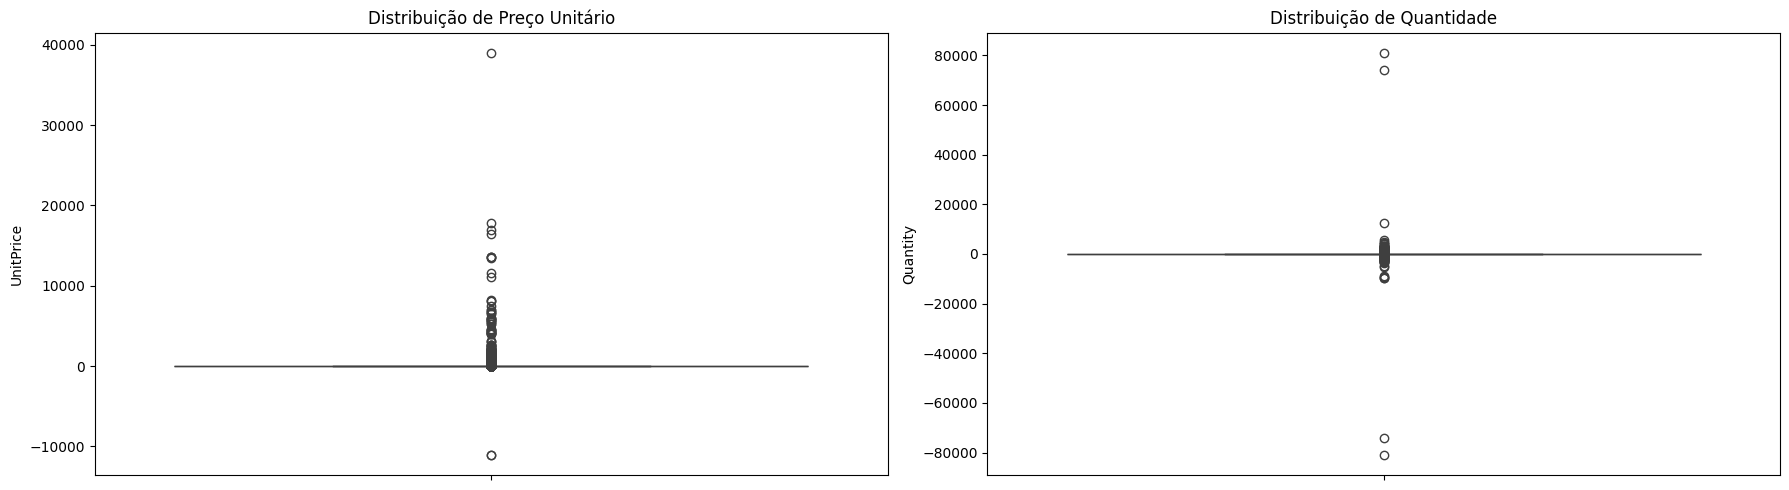

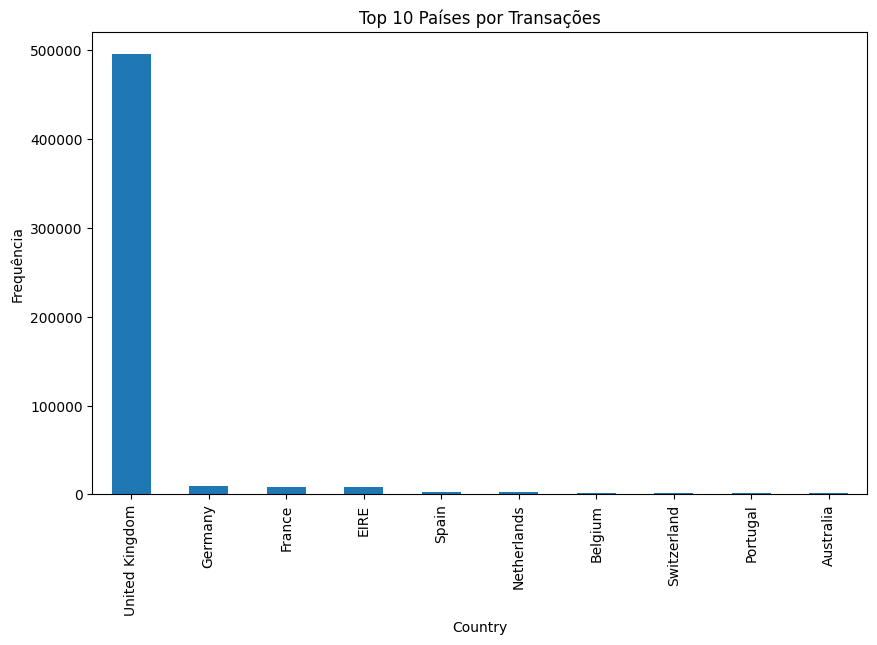

In [7]:
# 1. Distribuição de Preço e Quantidade (identificando outliers e escalas)
plt.figure(figsize=(18, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['UnitPrice'])
plt.title('Distribuição de Preço Unitário')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Quantity'])
plt.title('Distribuição de Quantidade')

plt.tight_layout()
plt.show()

# 2. Top 10 Países em volume de transações
plt.figure(figsize=(10, 6))
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Países por Transações')
plt.ylabel('Frequência')
plt.show()

c:\Users\leoss\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\leoss\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


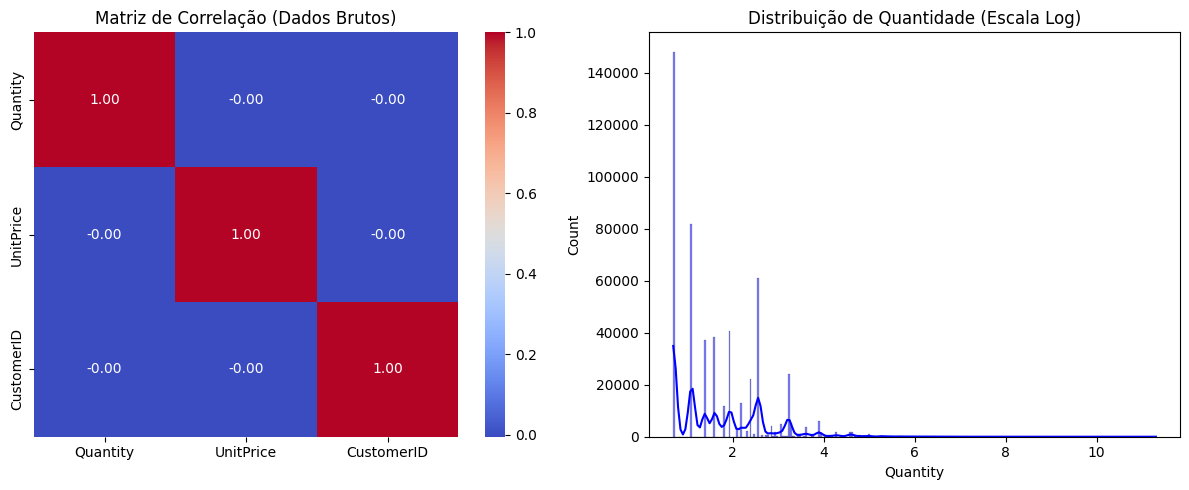

In [8]:
# EDA Diagnóstica (Antes do Pré-processamento)

# Selecionando apenas colunas numéricas para evitar erros de tipo
# O dropna aqui é apenas temporário para a visualização não quebrar
df[['Quantity', 'UnitPrice', 'CustomerID', 'InvoiceDate']].dropna()
df_temp = df[['Quantity', 'UnitPrice', 'CustomerID']]

plt.figure(figsize=(12, 5))

# 1. Matriz de Correlação: Verifica se as variáveis são independentes
plt.subplot(1, 2, 1)
sns.heatmap(df_temp.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação (Dados Brutos)')

# 2. Distribuição de Quantidade: Demonstra a assimetria e necessidade de escala
# Aplicamos log1p (logaritmo) apenas no gráfico para conseguir visualizar a densidade
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df_temp['Quantity']), kde=True, color='blue')
plt.title('Distribuição de Quantidade (Escala Log)')

plt.tight_layout()
plt.show()

## Pré-processamento Definitivo (RFM)

- Eliminação de dados inválidos
- Tratamento de valores ausentes
- Conversão de tipos
- Criação de features
- Normalização
- Seleção de features

In [9]:
# --- PRÉ-PROCESSAMENTO DEFINITIVO (RFM) ---

# 1. Eliminação de dados inválidos (Quantity e UnitPrice > 0, e valores ausentes) e duplicados
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
df_clean.drop_duplicates(inplace=True)
df_clean.dropna(subset=['Quantity', 'UnitPrice', 'CustomerID' ,'InvoiceDate'], inplace=True)

# 2. Conversão de tipos
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# 3. Criação de features (Valor Total e métricas RFM)
df_clean['TotalSum'] = df_clean['Quantity'] * df_clean['UnitPrice']
snapshot_date = df_clean['InvoiceDate'].max() + pd.DateOffset(days=1)

# Agregando por cliente para criar Recência, Frequência e Monetário
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalSum': 'sum'
})

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSum': 'Monetary'
}, inplace=True)

# 4. Normalização (Log + StandardScaler para tratar assimetria)
# Aplicamos log para diminuir o peso dos outliers antes de normalizar
rfm_log = np.log1p(rfm)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# 5. Seleção de features para o Dataframe final
df_rfm_final = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

print(f"Base processada com sucesso. Total de clientes: {df_rfm_final.shape}")
print(df_rfm_final.head())

Base processada com sucesso. Total de clientes: (4338, 3)
             Recency  Frequency  Monetary
CustomerID                               
12346       1.461993  -0.955214  3.707716
12347      -2.038734   1.074425  1.414903
12348       0.373104   0.386304  0.720024
12349      -0.623086  -0.955214  0.702287
12350       1.424558  -0.955214 -0.614514


## EDA pré-limpeza

In [10]:
import sweetviz as sv

report = sv.analyze(df)
report.show_html('eda_preCleaning.html', open_browser=False)

                                             |          | [  0%]   00:00 -> (? left)

Report eda_preCleaning.html was generated.


## EDA pós-limpeza

In [11]:
import sweetviz as sv

report = sv.analyze(df_rfm_final)
report.show_html('eda_posCleaning.html', open_browser=False)

                                             |          | [  0%]   00:00 -> (? left)

Report eda_posCleaning.html was generated.


# Modelagem

- Negócio: Não procuramos poucos clusters como 2, pois ele é pouco informativo para o negócio. Assim como não buscamos valores muitos clusters
- Cluster sugeridos:
    - Cluster VIP -> baixo recência, alto frequência, alto monetário -> expectativa ~10% da base
    - Cluster Fiel -> baixo/ médio recência, médio/ alto frequência, médio/ alto monetário -> ~35% da base
    - Cluster Promissor -> média recência, média frequência, média monetário -> expectativa ~25% da base
    - Cluster Risco -> alta recência, baixa frequência, baixo monetário -> expectativa ~30% da base


## K-means

- Método do cotovelo: pegamos valores quando a curva tende a suavizar/ inércia
- Silhouette: tentamos pegar o valor máximo
- Davies–Bouldin: tentamos pegar melhor valor

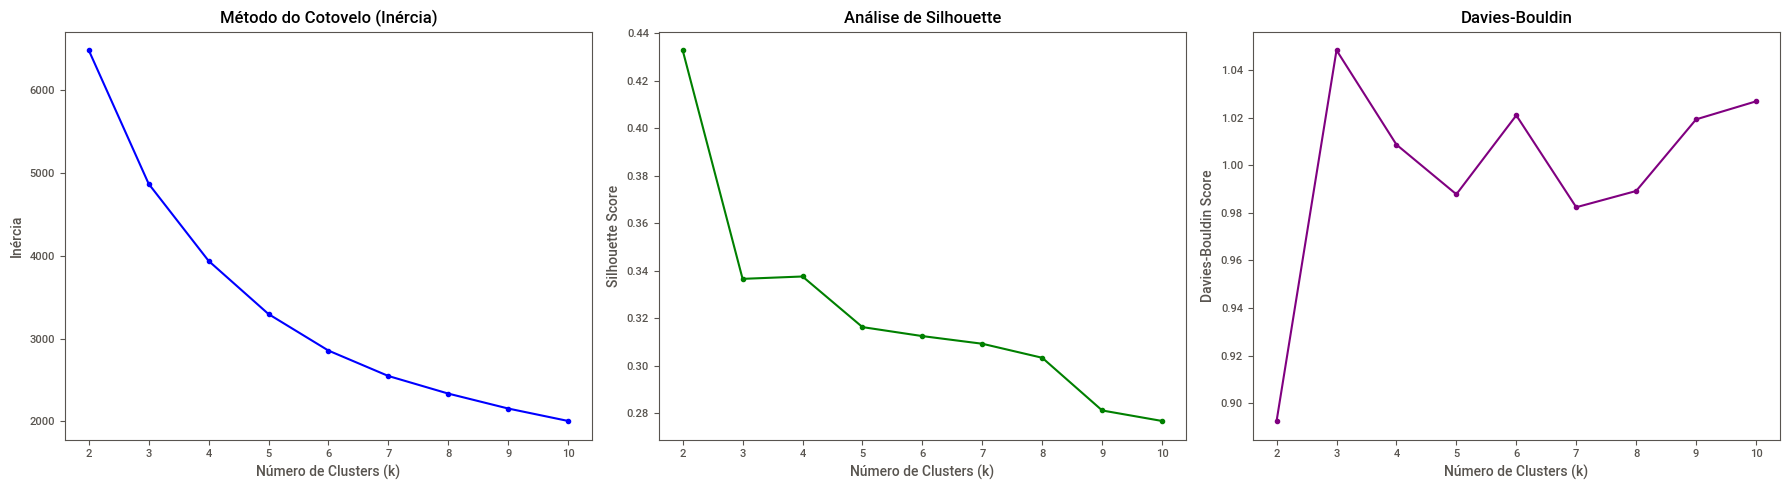

In [12]:
# --- MODELAGEM E AVALIAÇÃO QUANTITATIVA ---

# 1. Calculando Inércia, Silhouette e Davies-Bouldin para diferentes valores de K
inertia = []
silhouette_vals = []
davies_bouldin_vals = []
k_range = range(2, 11) # Testando de 2 a 10 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_rfm_final)
    inertia.append(kmeans.inertia_)
    silhouette_vals.append(silhouette_score(df_rfm_final, kmeans.labels_))
    davies_bouldin_vals.append(davies_bouldin_score(df_rfm_final, kmeans.labels_))

# 2. Visualização dos resultados para decisão de K
plt.figure(figsize=(18, 5))

# Gráfico do Cotovelo (Inércia)
plt.subplot(1, 3, 1)
plt.plot(k_range, inertia, marker='o', color='blue')
plt.title('Método do Cotovelo (Inércia)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')

# Gráfico do Silhouette Score
plt.subplot(1, 3, 2)
plt.plot(k_range, silhouette_vals, marker='o', color='green')
plt.title('Análise de Silhouette')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')

# Davies-Bouldin (menor é melhor)
plt.subplot(1, 3, 3)
plt.plot(k_range, davies_bouldin_vals, marker='o', color='purple')
plt.title('Davies-Bouldin')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Davies-Bouldin Score')

plt.tight_layout()
plt.show()

- Método do cotovelo: não vemos um patamar de cotovelo óbvio
- Silhouette: vemos um patamar aceitável em 3 e 4. Valor aceitável em 5
- Davies–Bouldin: vemos um mínimo em 7 e 5. Valores aceitáveis em 4, 6 e 8

In [13]:
# --- EXECUÇÃO K-MEANS (K=5) ---
k5 = 5
kmeans = KMeans(n_clusters=k5, init='k-means++', random_state=42, n_init=10)

# Criando colunas específicas
df_rfm_final['Cluster'] = kmeans.fit_predict(df_rfm_final[['Recency', 'Frequency', 'Monetary']])
rfm['Cluster'] = df_rfm_final['Cluster']

# Avaliação Qualitativa
perfil = df_rfm_final.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Total_Clientes'})

print(perfil)

          Recency  Frequency  Monetary  Total_Clientes
Cluster                                               
0       -0.540337  -0.599913 -0.634479             834
1       -0.890659   0.766277  0.731211             938
2        1.033577  -0.835743 -0.923325            1209
3        0.476359   0.018411  0.320861            1018
4       -1.322860   2.280918  1.867087             339


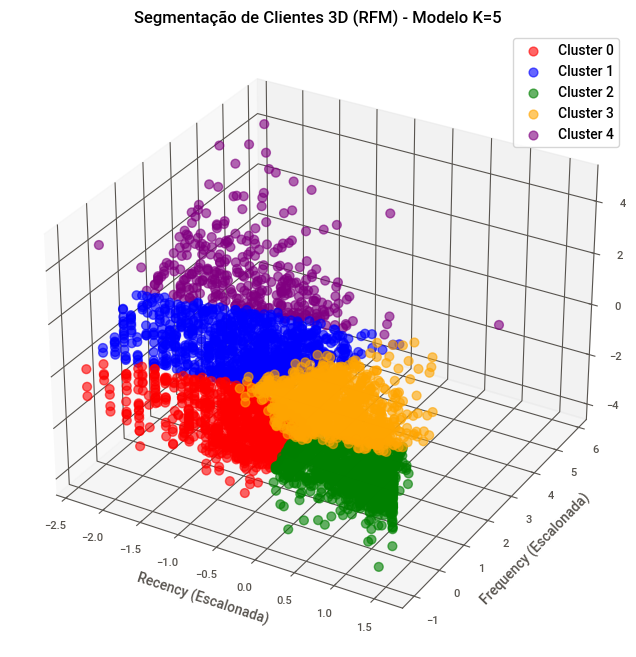

In [14]:
# --- VISUALIZAÇÃO 3D ---

# Configuração da figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Definindo as cores para os 5 clusters
cores_k5 = ['red', 'blue', 'green', 'orange', 'purple']

for i in range(k5):
    ax.scatter(df_rfm_final[df_rfm_final['Cluster'] == i]['Recency'],
               df_rfm_final[df_rfm_final['Cluster'] == i]['Frequency'],
               df_rfm_final[df_rfm_final['Cluster'] == i]['Monetary'],
               c=cores_k5[i], label=f'Cluster {i}', s=40, alpha=0.6)

ax.set_xlabel('Recency (Escalonada)')
ax.set_ylabel('Frequency (Escalonada)')
ax.set_zlabel('Monetary (Escalonada)')
ax.set_title('Segmentação de Clientes 3D (RFM) - Modelo K=5')
ax.legend()
plt.show()

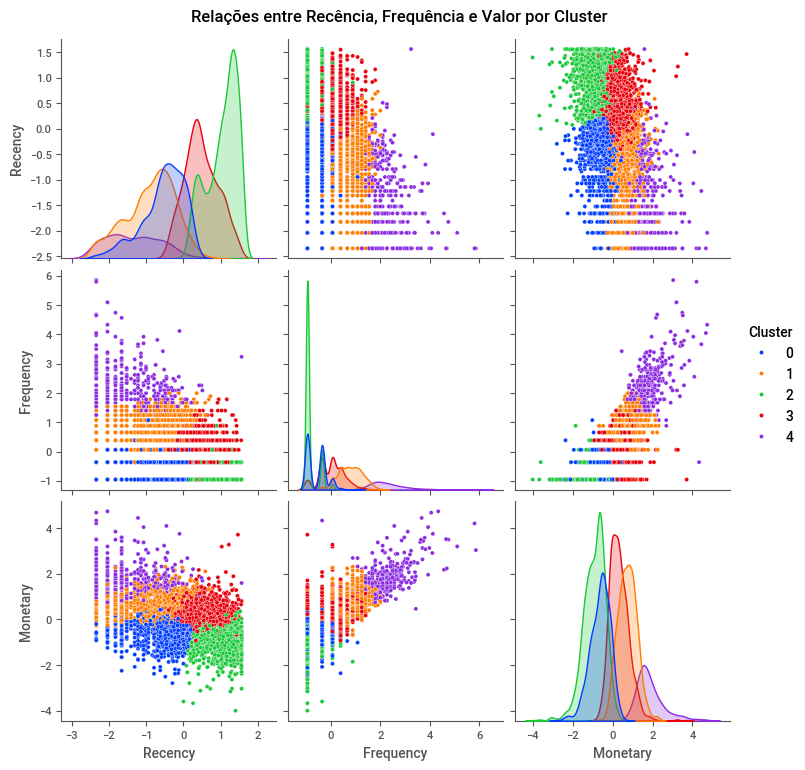

In [15]:
# Gerando o gráfico de pares
sns.pairplot(df_rfm_final[['Recency', 'Frequency', 'Monetary', 'Cluster']], hue='Cluster', palette='bright', diag_kind='kde')
plt.suptitle('Relações entre Recência, Frequência e Valor por Cluster', y=1.02)
plt.show()

In [16]:
# Mapeamento qualitativo
nomes_clusters_kmeans = {
    4: 'VIP',
    1: 'Fiel',
    3: 'Fiel',
    2: 'Risco',
    0: 'Promissor'
}

df_rfm_final['Segmento_KMeans'] = df_rfm_final['Cluster'].map(nomes_clusters_kmeans)


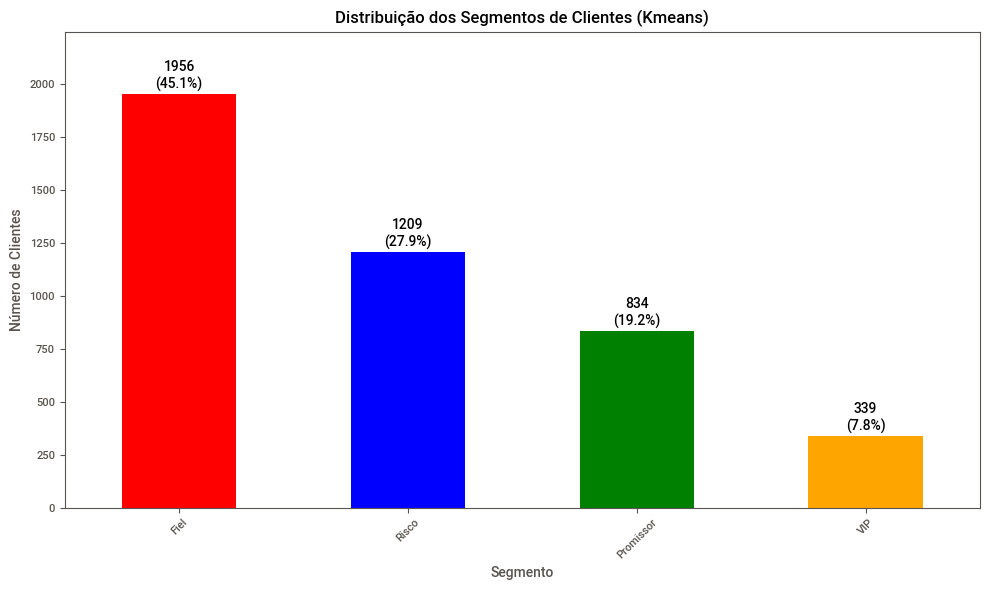

In [17]:
# Ver em forma de gráfica
plt.figure(figsize=(10, 6))

# Calculamos as duas métricas
contagem = df_rfm_final['Segmento_KMeans'].value_counts()
porcentagem = df_rfm_final['Segmento_KMeans'].value_counts(normalize=True) * 100

# Criamos o gráfico principal (usando os números absolutos no eixo Y)
contagem.plot(kind='bar', color=cores_k5)

# Adicionamos os rótulos combinados (Número + %) no topo de cada barra
for i, (label, valor_absoluto) in enumerate(contagem.items()):
    pct = porcentagem[label]
    texto = f"{valor_absoluto}\n({pct:.1f}%)" # \n quebra a linha para ficar um sobre o outro
    plt.text(i, valor_absoluto + 10, texto, ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('Distribuição dos Segmentos de Clientes (Kmeans)')
plt.xlabel('Segmento')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45)

# Aumentar um pouco o limite do eixo Y para o texto não cortar no topo
plt.ylim(0, contagem.max() * 1.15)

plt.tight_layout()
plt.show()

## DBSCAN

Hiperparâmetros principais: **`eps`** (raio da vizinhança) e **`min_samples`** (mínimo de pontos para núcleo denso). Por padrão, definimos min_samples=2*features (neste caso 6)
- Análise de ruído
- Método do cotovelo

In [18]:
# Medindo ruído
def testar_dbscan(df, eps_values, min_samples=6):
    results = []
    features = df[['Recency', 'Frequency', 'Monetary']]
    
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(features)
        labels = db.labels_
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        perc_noise = (n_noise / len(df)) * 100
        
        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'perc_noise': round(perc_noise, 2)
        })
            
    return pd.DataFrame(results)

# Definindo intervalos de teste (baseado na escala Z-score dos seus dados)
eps_range = [0.2, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.7]

df_testes = testar_dbscan(df_rfm_final, eps_range)

# Mostrando apenas combinações que geraram mais de 2 clusters
print(df_testes.sort_values(by='n_noise', ascending=True))

    eps  min_samples  n_clusters  n_noise  perc_noise
7  0.70            6           1       32        0.74
6  0.60            6           1       41        0.95
5  0.50            6           3       64        1.48
4  0.45            6           2       81        1.87
3  0.40            6           3      121        2.79
2  0.35            6           3      175        4.03
1  0.30            6          10      297        6.85
0  0.20            6          31      770       17.75


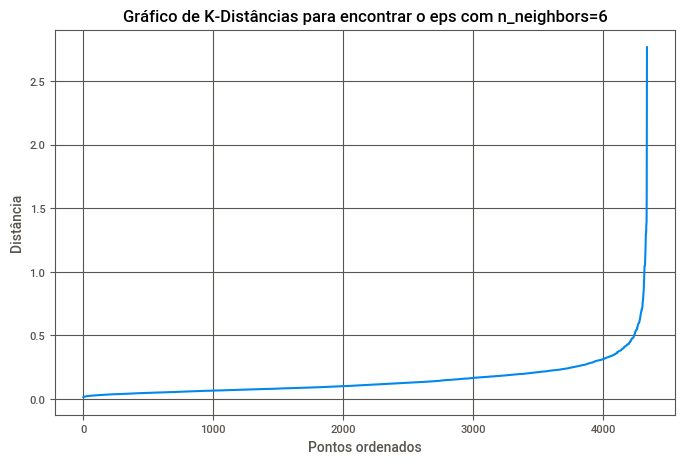

In [19]:
# Gráfico de K-Distâncias para eps=0.35
n_neighbors = 6

neighbors = NearestNeighbors(n_neighbors=n_neighbors)
neighbors_fit = neighbors.fit(df_rfm_final[['Recency', 'Frequency', 'Monetary']])
distances, indices = neighbors_fit.kneighbors(df_rfm_final[['Recency', 'Frequency', 'Monetary']])

# Ordenando as distâncias
distances = np.sort(distances[:, 4], axis=0)

# Plotando
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title(f'Gráfico de K-Distâncias para encontrar o eps com n_neighbors={n_neighbors}')
plt.xlabel('Pontos ordenados')
plt.ylabel('Distância')
plt.grid(True)
plt.show()

In [20]:
# Definido eps=0.35 pois possui bons números de clusters, minimiza ruído, e apresenta bom equilíbrio no gráfico de K-Distâncias
# Execução final do DBSCAN para comparação
dbscan_final = DBSCAN(eps=0.35, min_samples=6)
df_rfm_final['Cluster_DBSCAN'] = dbscan_final.fit_predict(df_rfm_final[['Recency', 'Frequency', 'Monetary']])

# Verificando as médias do DBSCAN para criar os nomes
perfil_dbscan = df_rfm_final.groupby('Cluster_DBSCAN').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster_DBSCAN': 'count' # Apenas para ver quantos clientes há em cada um
}).rename(columns={'Cluster_DBSCAN': 'Total_Clientes'})

print(perfil_dbscan)


                 Recency  Frequency  Monetary  Total_Clientes
Cluster_DBSCAN                                               
-1             -0.604823   1.336217  1.194165             175
 0             -0.491339   0.778198  0.648977            1878
 1              0.626018  -0.955214 -0.826579            1464
 2              0.136527  -0.361583 -0.265099             821


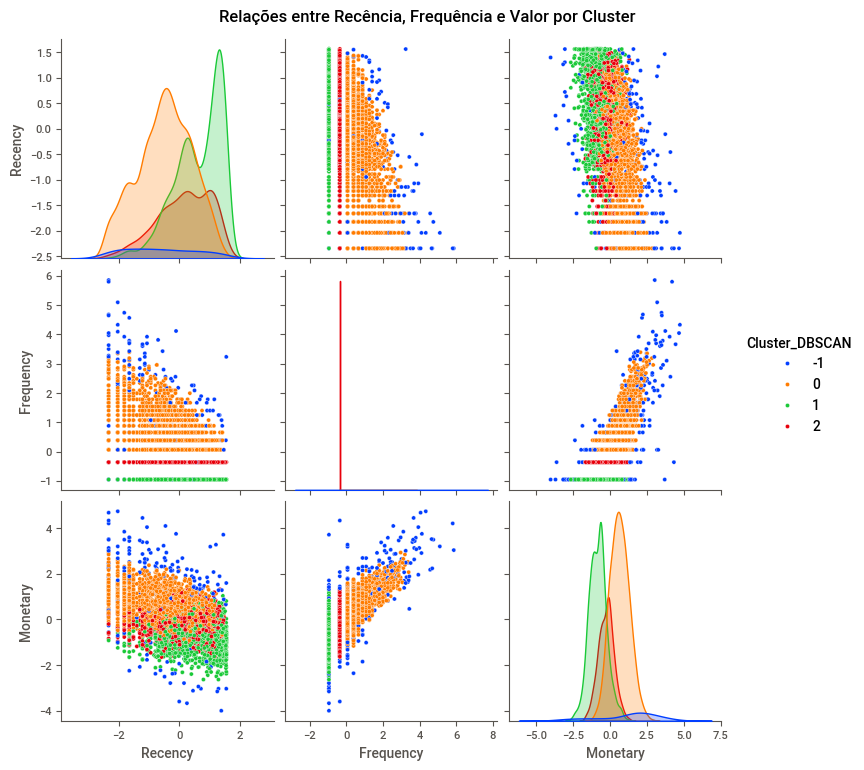

In [21]:
# Gerando o gráfico de pares
sns.pairplot(df_rfm_final[['Recency', 'Frequency', 'Monetary', 'Cluster_DBSCAN']], hue='Cluster_DBSCAN', palette='bright', diag_kind='kde')
plt.suptitle('Relações entre Recência, Frequência e Valor por Cluster', y=1.02)
plt.show()

In [22]:
# Mapeamento qualitativo
nomes_clusters_dbscan = {
    -1: 'Outlier',
     0: 'Fiel',
     2: 'Promissor',
     1: 'Risco'
}

# Aplicando o mapeamento
df_rfm_final['Segmento_DBSCAN'] = df_rfm_final['Cluster_DBSCAN'].map(nomes_clusters_dbscan)

# Buscando os clinetes VIPs (outliers bons)
condicao_vip = (df_rfm_final['Cluster_DBSCAN'] == -1) & (df_rfm_final['Monetary'] > df_rfm_final['Monetary'].quantile(0.75))
df_rfm_final.loc[condicao_vip, 'Segmento_DBSCAN'] = 'VIP'

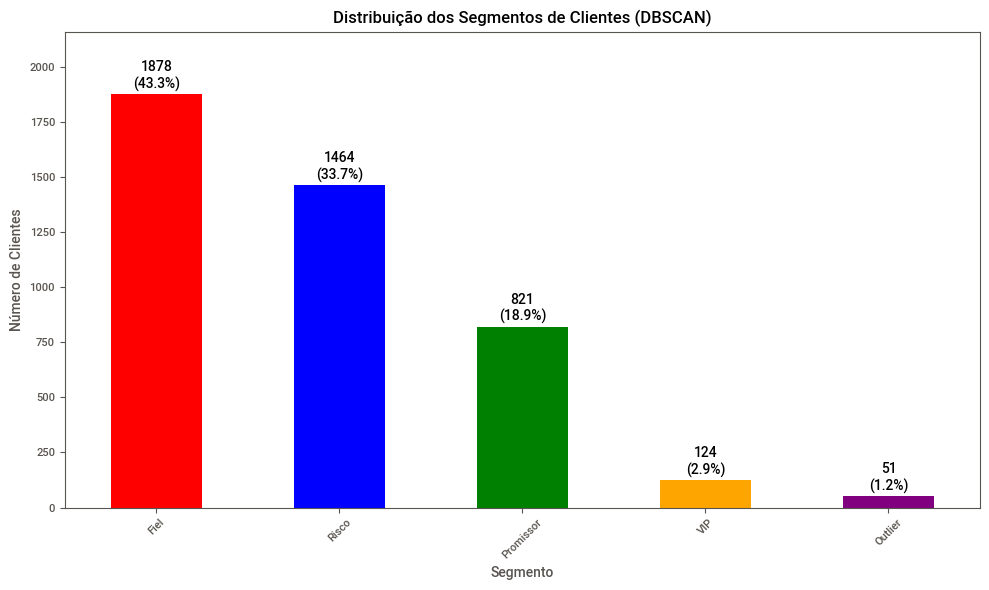

In [23]:
# Ver em forma de gráfica
plt.figure(figsize=(10, 6))

# Calculamos as duas métricas
contagem = df_rfm_final['Segmento_DBSCAN'].value_counts()
porcentagem = df_rfm_final['Segmento_DBSCAN'].value_counts(normalize=True) * 100

# Criamos o gráfico principal (usando os números absolutos no eixo Y)
contagem.plot(kind='bar', color=cores_k5)

# Adicionamos os rótulos combinados (Número + %) no topo de cada barra
for i, (label, valor_absoluto) in enumerate(contagem.items()):
    pct = porcentagem[label]
    texto = f"{valor_absoluto}\n({pct:.1f}%)" # \n quebra a linha para ficar um sobre o outro
    plt.text(i, valor_absoluto + 10, texto, ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('Distribuição dos Segmentos de Clientes (DBSCAN)')
plt.xlabel('Segmento')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45)

# Aumentar um pouco o limite do eixo Y para o texto não cortar no topo
plt.ylim(0, contagem.max() * 1.15)

plt.tight_layout()
plt.show()

## HDBSCAN
Hiperparâmetros principais: **min_cluster_size_values** (número mínimo de dados por cluster)
- Análise de ruído
- Gráfcio de Silhouette

In [24]:
# Analise de ruído
def testar_hdbscan(df, min_cluster_size_values):
    results = []
    scores = []
    features = df[['Recency', 'Frequency', 'Monetary']]
    
    for mcs in min_cluster_size_values:
        # Inicializando o HDBSCAN
        hdb = HDBSCAN(min_cluster_size=mcs, copy=True).fit(features)
        labels = hdb.labels_
        
        # Número de clusters (ignora o ruído -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        # Contagem de ruído
        n_noise = list(labels).count(-1)
        # Percentual de ruído (importante para decidir se o modelo está sendo rígido demais)
        perc_noise = (n_noise / len(df)) * 100
        
        # Silhouette só funciona se houver mais de 1 cluster e ignora o ruído (-1)
        mask = labels != -1
        if len(set(labels[mask])) > 1:
            score = silhouette_score(features[mask], labels[mask])
            scores.append(score)
        else:
            scores.append(0)
        
        results.append({
            'min_cluster_size': mcs,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'perc_noise': round(perc_noise, 2),
            'silhouette_score': round(scores[-1], 3) if scores else 0
        })
            
    return pd.DataFrame(results)

min_cluster_size = range(10, 101, 5)

df_testes_hdb = testar_hdbscan(df_rfm_final, min_cluster_size)

print(df_testes_hdb.sort_values(by='perc_noise', ascending=True))

    min_cluster_size  n_clusters  n_noise  perc_noise  silhouette_score
6                 40           2      467       10.77             0.319
7                 45           2      534       12.31             0.323
2                 20           3      584       13.46             0.191
8                 50           2      594       13.69             0.327
9                 55           2      656       15.12             0.330
10                60           2      702       16.18             0.333
3                 25           3      740       17.06             0.199
11                65           2      753       17.36             0.335
1                 15           4      798       18.40             0.145
12                70           2      818       18.86             0.338
0                 10           5      828       19.09             0.124
13                75           2      878       20.24             0.341
4                 30           3      882       20.33           

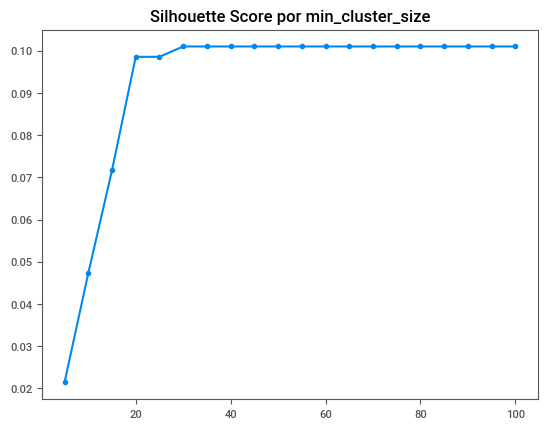

In [25]:
features = df_rfm_final[['Recency', 'Frequency', 'Monetary']]
min_cluster_size = range(5, 101, 5)
scores = []

for mcs in min_cluster_size:
    model = HDBSCAN(min_cluster_size=mcs, min_samples=6, copy=True)
    labels = model.fit_predict(features)
    
    # Silhouette só funciona se houver mais de 1 cluster e ignora o ruído (-1)
    mask = labels != -1
    if len(set(labels[mask])) > 1:
        score = silhouette_score(features[mask], labels[mask])
        scores.append(score)
    else:
        scores.append(0)

# O pico deste gráfico indica o melhor mcs
plt.plot(min_cluster_size, scores, marker='o')
plt.title('Silhouette Score por min_cluster_size')
plt.show()

In [26]:
# Pegamos min_cluster_size=20, pois atingiu um bom número de clusters e um percentual de ruído baixo, além de ser um ponto bom para o gráfico de Silhouette

# 1. Redefinindo as variáveis necessárias (garante que não dê erro de 'not defined')
rfm_cols = ['Recency', 'Frequency', 'Monetary']
X_all = df_rfm_final[rfm_cols]

# 2. Configurando o modelo baseado no seu teste vencedor (Linha 3 da sua tabela)
# min_cluster_size=250 e min_samples=2 geraram 5 clusters estáveis
modelo_hdb = HDBSCAN(
    min_cluster_size=20, 
    copy=True
)

# 3. Aplicando o modelo
df_rfm_final['Cluster_HDBSCAN'] = modelo_hdb.fit_predict(X_all)

# 4. Criando o Perfil para análise

perfil_hdb = df_rfm_final.groupby('Cluster_HDBSCAN').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster_HDBSCAN': 'count' # Apenas para ver quantos clientes há em cada um
}).rename(columns={'Cluster_HDBSCAN': 'Total_Clientes'})

print(perfil_hdb)

                  Recency  Frequency  Monetary  Total_Clientes
Cluster_HDBSCAN                                               
-1              -0.831174   1.035359  0.883637             584
 0               0.646333  -0.955214 -0.827804            1443
 1               0.216992  -0.361583 -0.266492             748
 2              -0.389996   0.668067  0.561620            1563


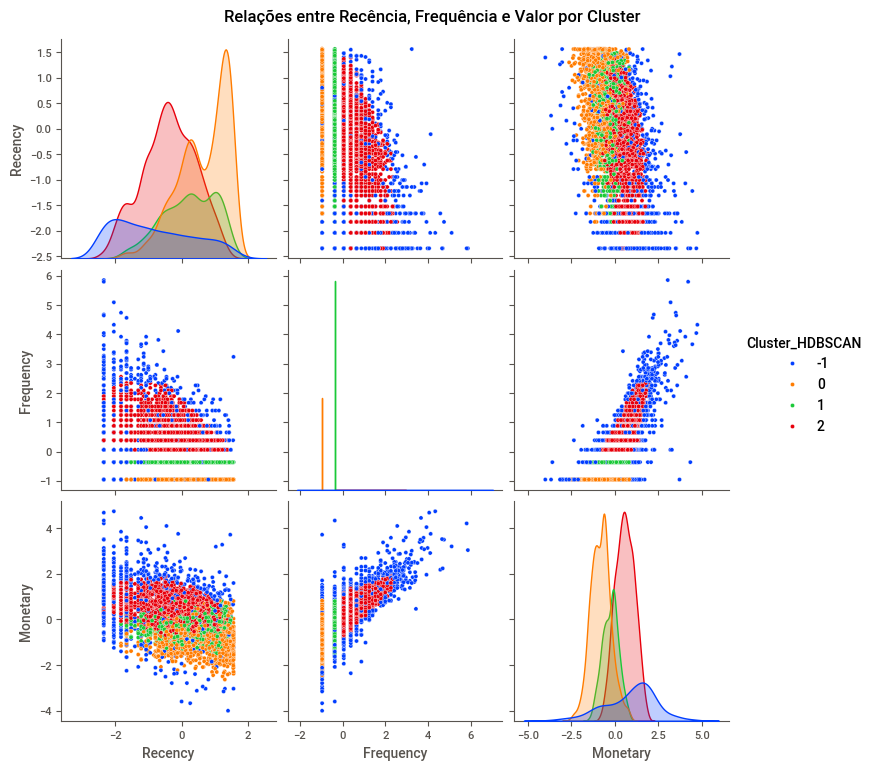

In [27]:
# Gerando o gráfico de pares
sns.pairplot(df_rfm_final[['Recency', 'Frequency', 'Monetary', 'Cluster_HDBSCAN']], hue='Cluster_HDBSCAN', palette='bright', diag_kind='kde')
plt.suptitle('Relações entre Recência, Frequência e Valor por Cluster', y=1.02)
plt.show()

In [28]:
# Mapeamento qualitativo
nomes_clusters_hdbscan = {
    -1: 'Outlier',
    2: 'Fiel',
    1: 'Promissor',
    0: 'Risco'
}

# Aplicando o mapeamento
df_rfm_final['Segmento_HDBSCAN'] = df_rfm_final['Cluster_HDBSCAN'].map(nomes_clusters_hdbscan)

# Buscando os clinetes VIPs (outliers bons)
condicao_vip = (df_rfm_final['Cluster_HDBSCAN'] == -1) & (df_rfm_final['Monetary'] > df_rfm_final['Monetary'].quantile(0.75))
df_rfm_final.loc[condicao_vip, 'Segmento_HDBSCAN'] = 'VIP'

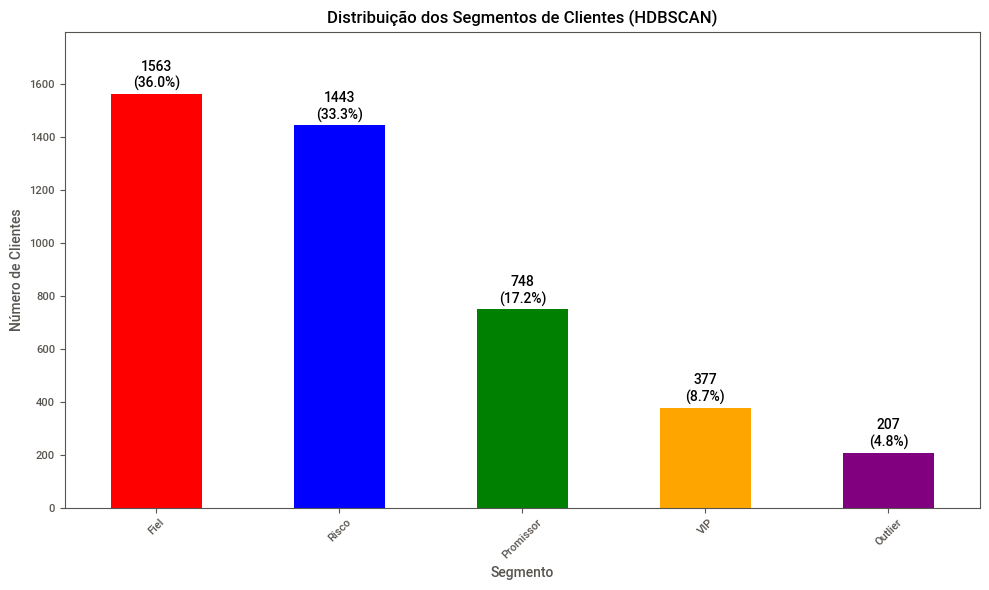

In [29]:
# Ver em forma de gráfica
plt.figure(figsize=(10, 6))

# Calculamos as duas métricas
contagem = df_rfm_final['Segmento_HDBSCAN'].value_counts()
porcentagem = df_rfm_final['Segmento_HDBSCAN'].value_counts(normalize=True) * 100

# Criamos o gráfico principal (usando os números absolutos no eixo Y)
contagem.plot(kind='bar', color=cores_k5)

# Adiciona7557
# mos os rótulos combinados (Número + %) no topo de cada barra
for i, (label, valor_absoluto) in enumerate(contagem.items()):
    pct = porcentagem[label]
    texto = f"{valor_absoluto}\n({pct:.1f}%)" # \n quebra a linha para ficar um sobre o outro
    plt.text(i, valor_absoluto + 10, texto, ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('Distribuição dos Segmentos de Clientes (HDBSCAN)')
plt.xlabel('Segmento')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45)

# Aumentar um pouco o limite do eixo Y para o texto não cortar no topo
plt.ylim(0, contagem.max() * 1.15)

plt.tight_layout()
plt.show()

# Agrupamento hierárquico (Hierarchical Clustering)

Aplicamos os critérios de ligação: Ward: (minimiza variância intra-cluster), Single (encadeamento mínimo, tende a chaining), Complete (encadeamento máximo, clusters mais compactos) 

Métodos de análise:
- Dendograma
- Mojena


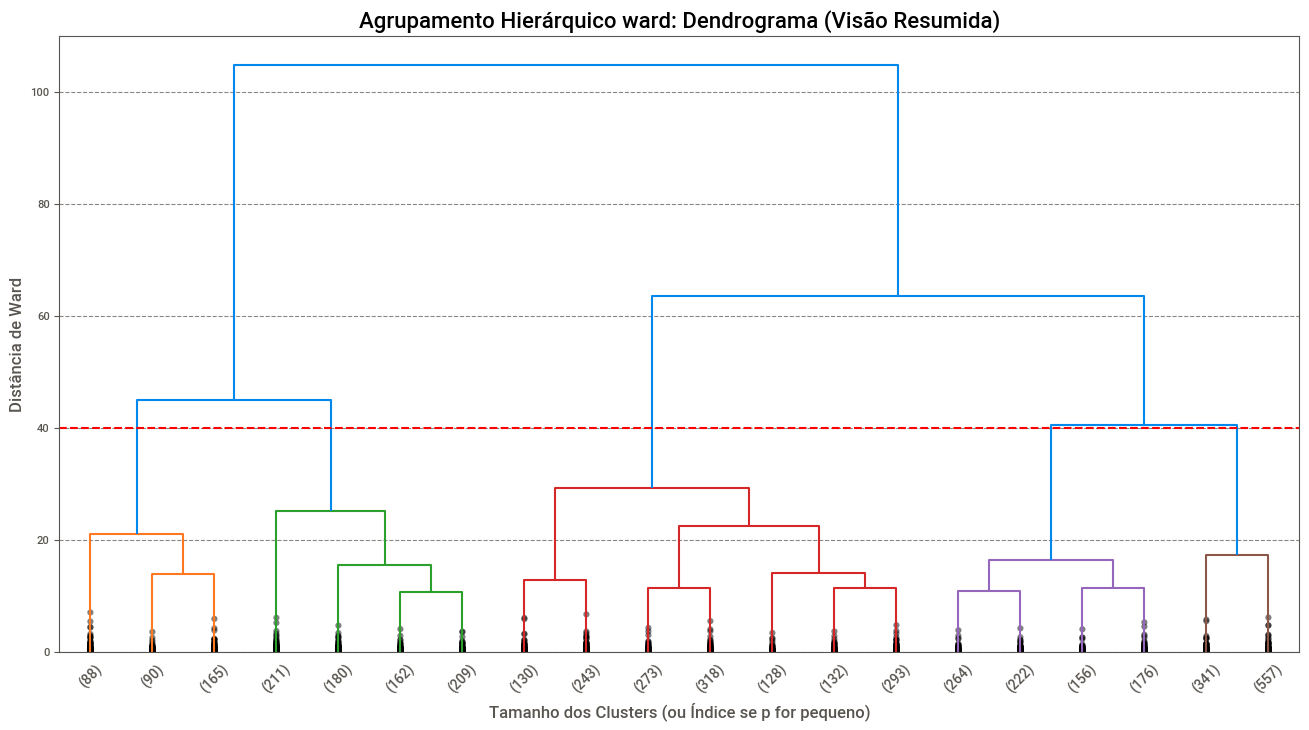

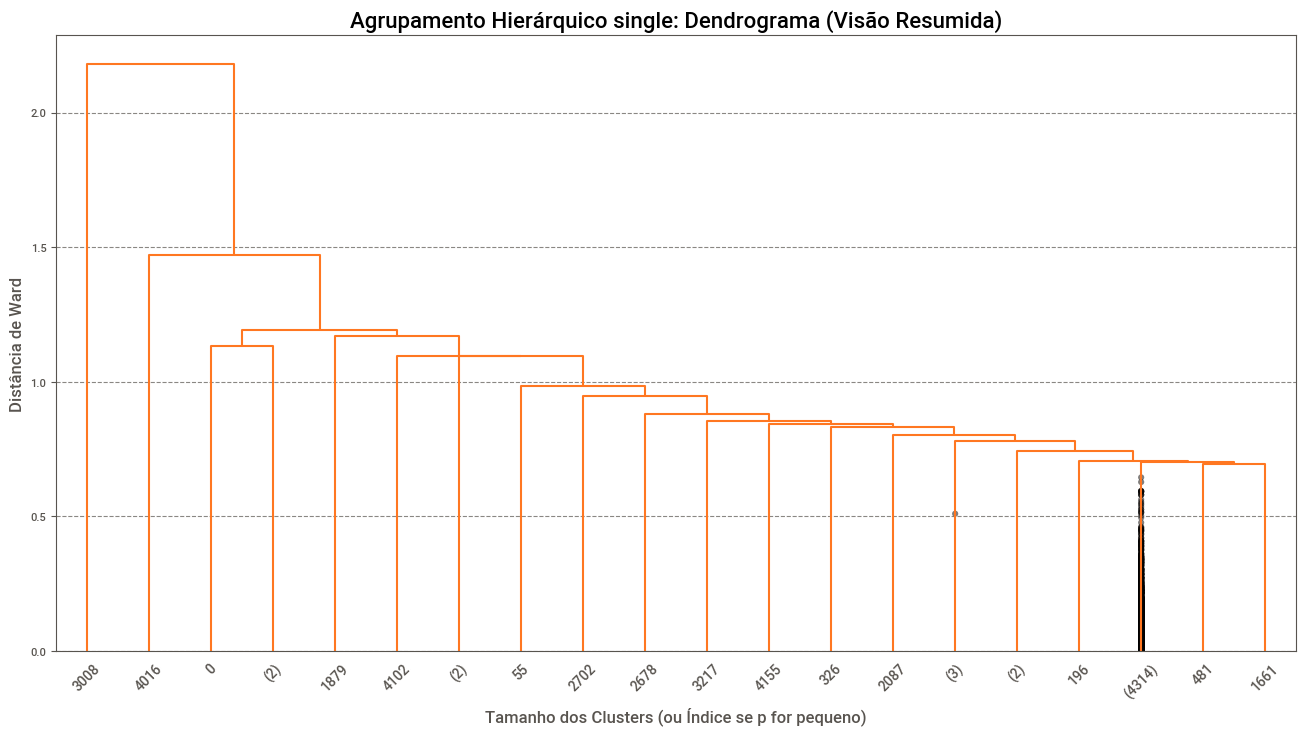

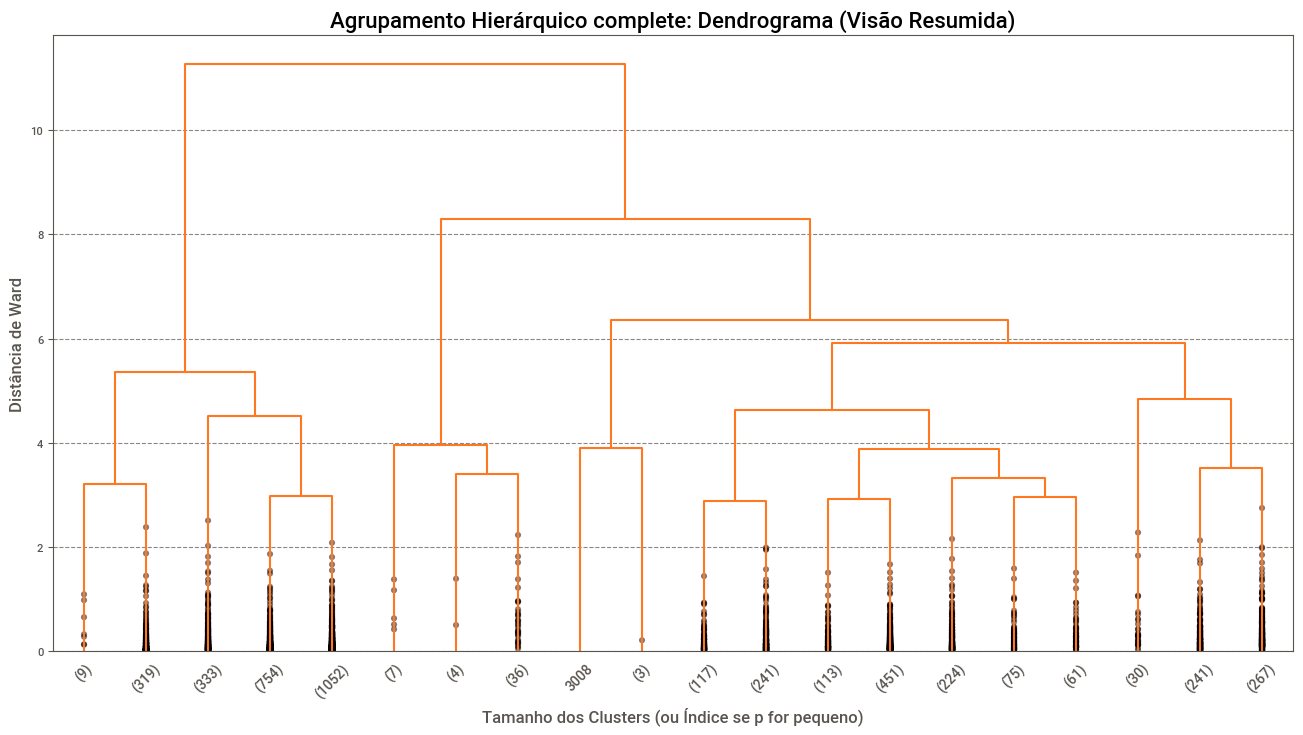

In [30]:
rfm_cols = ['Recency', 'Frequency', 'Monetary']
X_all = df_rfm_final[rfm_cols]
methods = ["ward", 'single',"complete"]

for method in methods:
    Z = linkage(X_all, method=method)

    plt.figure(figsize=(16, 8))

    # Dendrograma:
    dendrogram_plot = dendrogram(
        Z, 
        truncate_mode='lastp', # condensa os dados em 'p' clusters finais
        p=20,                  # Mostra apenas os últimos 20 agrupamentos
        leaf_rotation=45.,
        leaf_font_size=10.,
        show_contracted=True,  # Mostra pontinhos pretos onde há ramos ocultos
        color_threshold=40     # Muda a cor dos ramos abaixo dessa distância
    )

    # Adicionando uma linha de corte horizontal (opcional)
    plt.axhline(y=40, color='r', linestyle='--')

    plt.title(f'Agrupamento Hierárquico {method}: Dendrograma (Visão Resumida)', fontsize=16)
    plt.xlabel('Tamanho dos Clusters (ou Índice se p for pequeno)', fontsize=12)
    plt.ylabel('Distância de Ward', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7) # Grid suave para facilitar leitura da distância

    plt.show()

In [31]:
# Vamos aplicar o método o método de Mojena para o Ward
# Aplica o método de Ward para o agrupamento hierárquico
Z = linkage(X_all, method='ward')
Z

array([[3.46900000e+03, 3.95800000e+03, 8.26105800e-05, 2.00000000e+00],
       [7.23000000e+02, 4.24700000e+03, 3.72657990e-04, 2.00000000e+00],
       [2.63400000e+03, 3.38400000e+03, 4.18527982e-04, 2.00000000e+00],
       ...,
       [8.66700000e+03, 8.66900000e+03, 4.48943121e+01, 1.10500000e+03],
       [8.67000000e+03, 8.67100000e+03, 6.35385660e+01, 3.23300000e+03],
       [8.67200000e+03, 8.67300000e+03, 1.04827563e+02, 4.33800000e+03]],
      shape=(4337, 4))

C:\Users\leoss\AppData\Local\Temp\ipykernel_31096\3249524194.py:17: RuntimeWarning: divide by zero encountered in scalar divide
  mojena_k = (distances[-1] - mean_dist) / std_dist


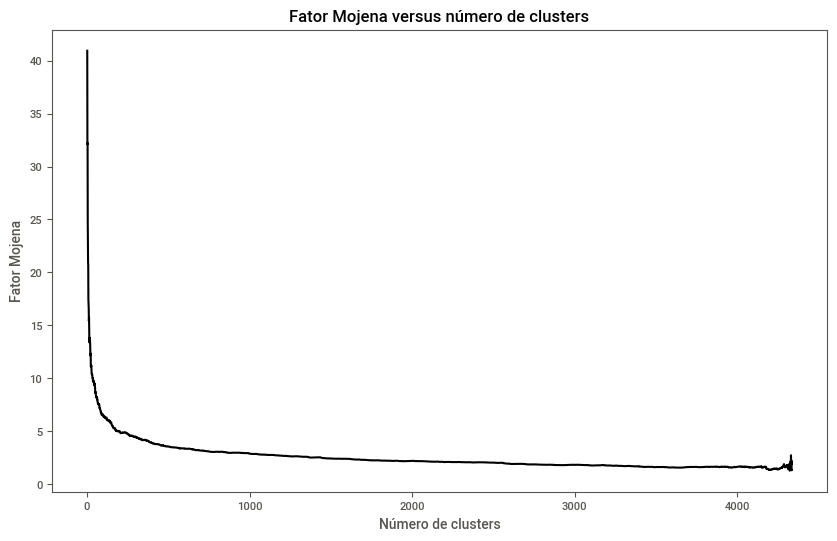

In [32]:
# Implementação do Método de Mojena
def mojena_fator(Z):
    """
    Implementa o método de Mojena para agrupamento hierárquico.
    Z: Matriz linkage do scipy
    k_factor: Valor padrão geralmente entre 1.25 e 1.50
    """
    # Distâncias de fusão (terceira coluna da matriz Z)
    distances = Z[:, 2]

    # Calcular média e desvio padrão das distâncias
    mean_dist = np.mean(distances[0:-1])
    std_dist = np.std(distances[0:-1])

    # Calcular critério de Mojena (k) para cada estágio
    # k_j = (alpha_j - mean) / std
    mojena_k = (distances[-1] - mean_dist) / std_dist

    return mojena_k

moj_factor = []
N = len(Z)

N_clusters_values = list(range(2, N))
for i in N_clusters_values:
    aux = Z[0:i, :]
    moj_factor.append(mojena_fator(aux))

# Reverse both the moj_factor list and the list of cluster numbers for plotting
moj_factor.reverse()

plt.figure(figsize=(10, 6))
plt.plot(N_clusters_values, moj_factor, color='black')
plt.title('Fator Mojena versus número de clusters')
plt.xlabel('Número de clusters')
plt.ylabel('Fator Mojena')
plt.show()

In [33]:
# Função para encontrar o melhor número de clusters baseado no fator Mojena

def mojena_stopping_rule(Z, k_factor):
    """
    Implementa o método de Mojena para agrupamento hierárquico.
    Z: Matriz linkage do scipy
    k_factor: Valor padrão geralmente entre 1.25 e 1.50
    """
    # Distâncias de fusão (terceira coluna da matriz Z)
    distances = Z[:, 2]

    # Calcular média e desvio padrão das distâncias
    mean_dist = np.mean(distances)
    std_dist = np.std(distances)

    # Calcular critério de Mojena (k) para cada estágio
    # k_j = (alpha_j - mean) / std
    mojena_k = (distances - mean_dist) / std_dist

    # Encontrar o estágio onde a distância é "significativamente" maior
    # O corte é geralmente onde mojena_k > k_factor
    # Pegamos o último estágio que está abaixo do limite para cortar

    stopping_stage = np.argmax(mojena_k > k_factor) - 1

    # Número de clusters = Total de elementos - estágio de parada
    num_clusters = len(distances) - stopping_stage

    return num_clusters, mojena_k

n_clusters, k_values = mojena_stopping_rule(Z, k_factor=1.25)
print(f"Número ideal de clusters (Mojena): {n_clusters}")

Número ideal de clusters (Mojena): 77


In [34]:
# Treinamento domodelo final de Hierárquico (Ward) com clusters = 5
N_CLUSTERS_HC = 5
rfm_cols = ['Recency', 'Frequency', 'Monetary']
X_all = df_rfm_final[rfm_cols]

hc = AgglomerativeClustering(
    n_clusters=N_CLUSTERS_HC,
    metric="euclidean",
    linkage="ward",
)
df_rfm_final['Cluster_Ward'] = hc.fit_predict(X_all)

# Verificando as médias do Ward para criar os nomes
perfil_hc_ward = df_rfm_final.groupby('Cluster_Ward').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster_Ward': 'count' # Apenas para ver quantos clientes há em cada um
}).rename(columns={'Cluster_Ward': 'Total_Clientes'})

print(perfil_hc_ward)

               Recency  Frequency  Monetary  Total_Clientes
Cluster_Ward                                               
0             0.302681   0.091025  0.363233            1517
1            -1.272768   0.631333  0.524287             762
2             1.194048  -0.851003 -0.990959             898
3            -1.210434   2.229856  1.828660             343
4            -0.178966  -0.757703 -0.840931             818


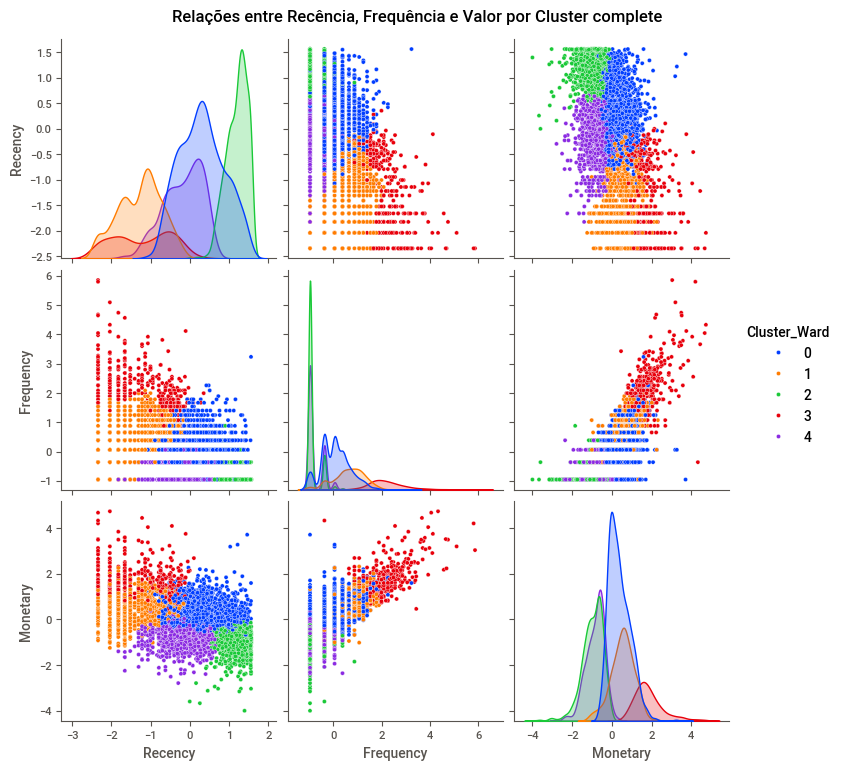

In [35]:
# Gerando o gráfico de pares
sns.pairplot(df_rfm_final[['Recency', 'Frequency', 'Monetary', "Cluster_Ward"]], hue="Cluster_Ward", palette='bright', diag_kind='kde')
plt.suptitle(f'Relações entre Recência, Frequência e Valor por Cluster {method}', y=1.02)
plt.show()

In [36]:
# Mapeamento qualitativo
nomes_clusters_ward = {
    3: "VIP",
    1: "Fiel",
    0: "Fiel",
    4: "Promissor",
    2: "Risco"
}

# Aplicando o mapeamento
df_rfm_final['Segmento_Ward'] = df_rfm_final['Cluster_Ward'].map(nomes_clusters_ward)

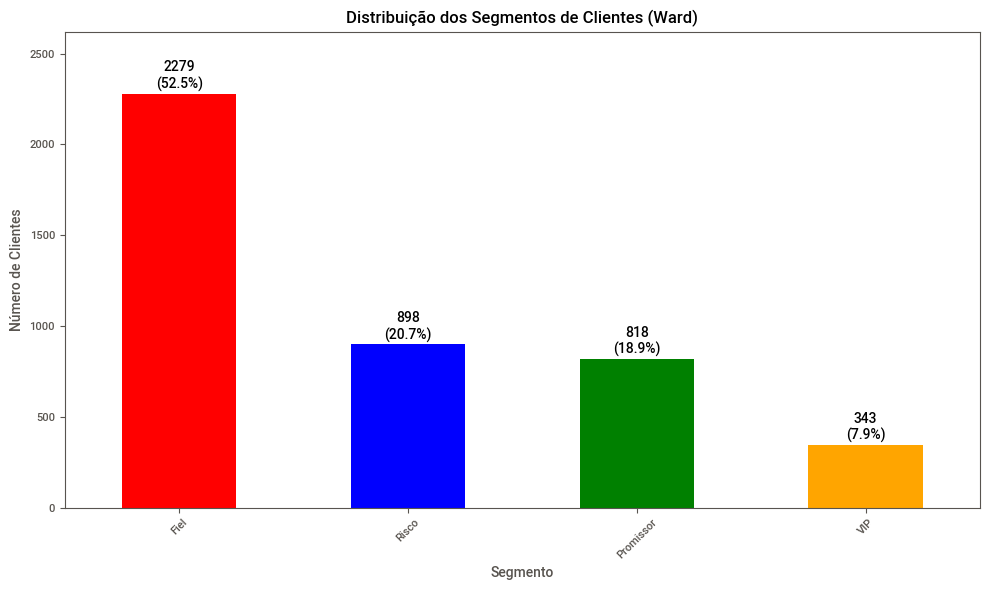

In [37]:
# Ver em forma de gráfica
plt.figure(figsize=(10, 6))

# Calculamos as duas métricas
contagem = df_rfm_final['Segmento_Ward'].value_counts()
porcentagem = df_rfm_final['Segmento_Ward'].value_counts(normalize=True) * 100

# Criamos o gráfico principal (usando os números absolutos no eixo Y)
contagem.plot(kind='bar', color=cores_k5)

# Adicionamos os rótulos combinados (Número + %) no topo de cada barra
for i, (label, valor_absoluto) in enumerate(contagem.items()):
    pct = porcentagem[label]
    texto = f"{valor_absoluto}\n({pct:.1f}%)" # \n quebra a linha para ficar um sobre o outro
    plt.text(i, valor_absoluto + 10, texto, ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('Distribuição dos Segmentos de Clientes (Ward)')
plt.xlabel('Segmento')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45)

# Aumentar um pouco o limite do eixo Y para o texto não cortar no topo
plt.ylim(0, contagem.max() * 1.15)

plt.tight_layout()
plt.show()

# Comparação de Métodos

- Heatmaps comparações entre métodos
- Adjusted Rand Index (ARI) entre todos os pares de segmentações (acima de zero indica concordância maior que o acaso; 1 = mesma partição)
- Score de Silhouette
- Tabela de contagens por segmento em cada método

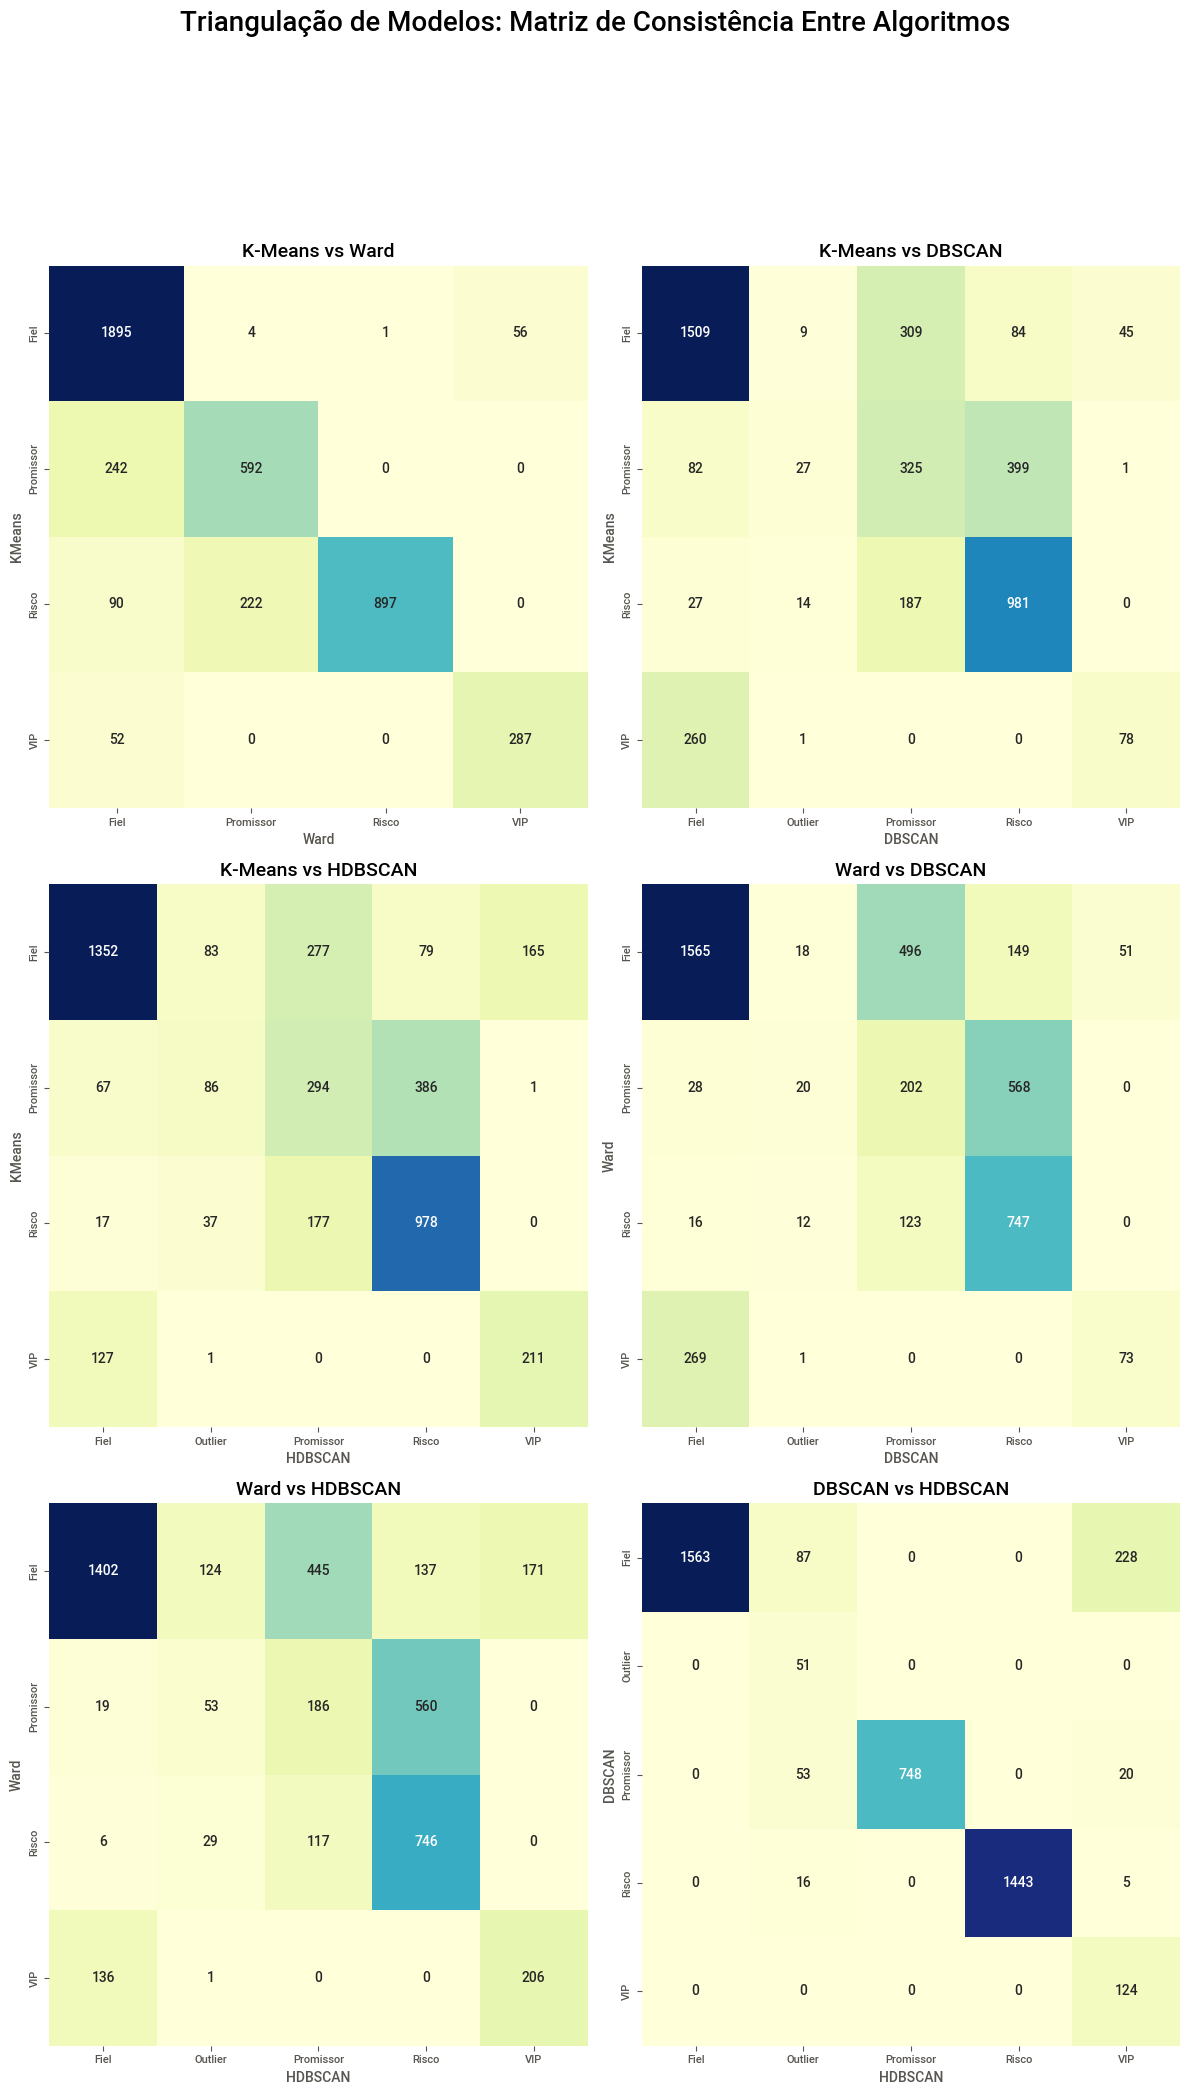

In [38]:
# 1. Definimos os pares de comparação
comparacoes = [
    ('Segmento_KMeans', 'Segmento_Ward', 'K-Means vs Ward'),
    ('Segmento_KMeans', 'Segmento_DBSCAN', 'K-Means vs DBSCAN'),
    ('Segmento_KMeans', 'Segmento_HDBSCAN', 'K-Means vs HDBSCAN'),
    ('Segmento_Ward', 'Segmento_DBSCAN', 'Ward vs DBSCAN'),
    ('Segmento_Ward', 'Segmento_HDBSCAN', 'Ward vs HDBSCAN'),
    ('Segmento_DBSCAN', 'Segmento_HDBSCAN', 'DBSCAN vs HDBSCAN')
]

# 2. Criamos a moldura (3 linhas, 2 colunas)
fig, axes = plt.subplots(3, 2, figsize=(12, 22))
fig.suptitle('Triangulação de Modelos: Matriz de Consistência Entre Algoritmos', fontsize=20)

# O segredo está no .flatten() aqui embaixo:
for i, (col_y, col_x, titulo) in enumerate(comparacoes):
    ax = axes.flatten()[i] # Achata a matriz 3x2 em uma lista de 6 posições
    
    # Criando a tabela de cruzamento
    tabela_cruzada = pd.crosstab(df_rfm_final[col_y], df_rfm_final[col_x])
    
    # Plotando o Heatmap
    sns.heatmap(tabela_cruzada, annot=True, fmt='d', cmap='YlGnBu', ax=ax, cbar=False)
    
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xlabel(col_x.split('_')[-1])
    ax.set_ylabel(col_y.split('_')[-1])

# Opcional: Remover o último subplot se ele ficar vazio (já que você tem 5 comparações para 6 espaços)
if len(comparacoes) < 6:
    axes.flatten()[-1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.90])
plt.show()

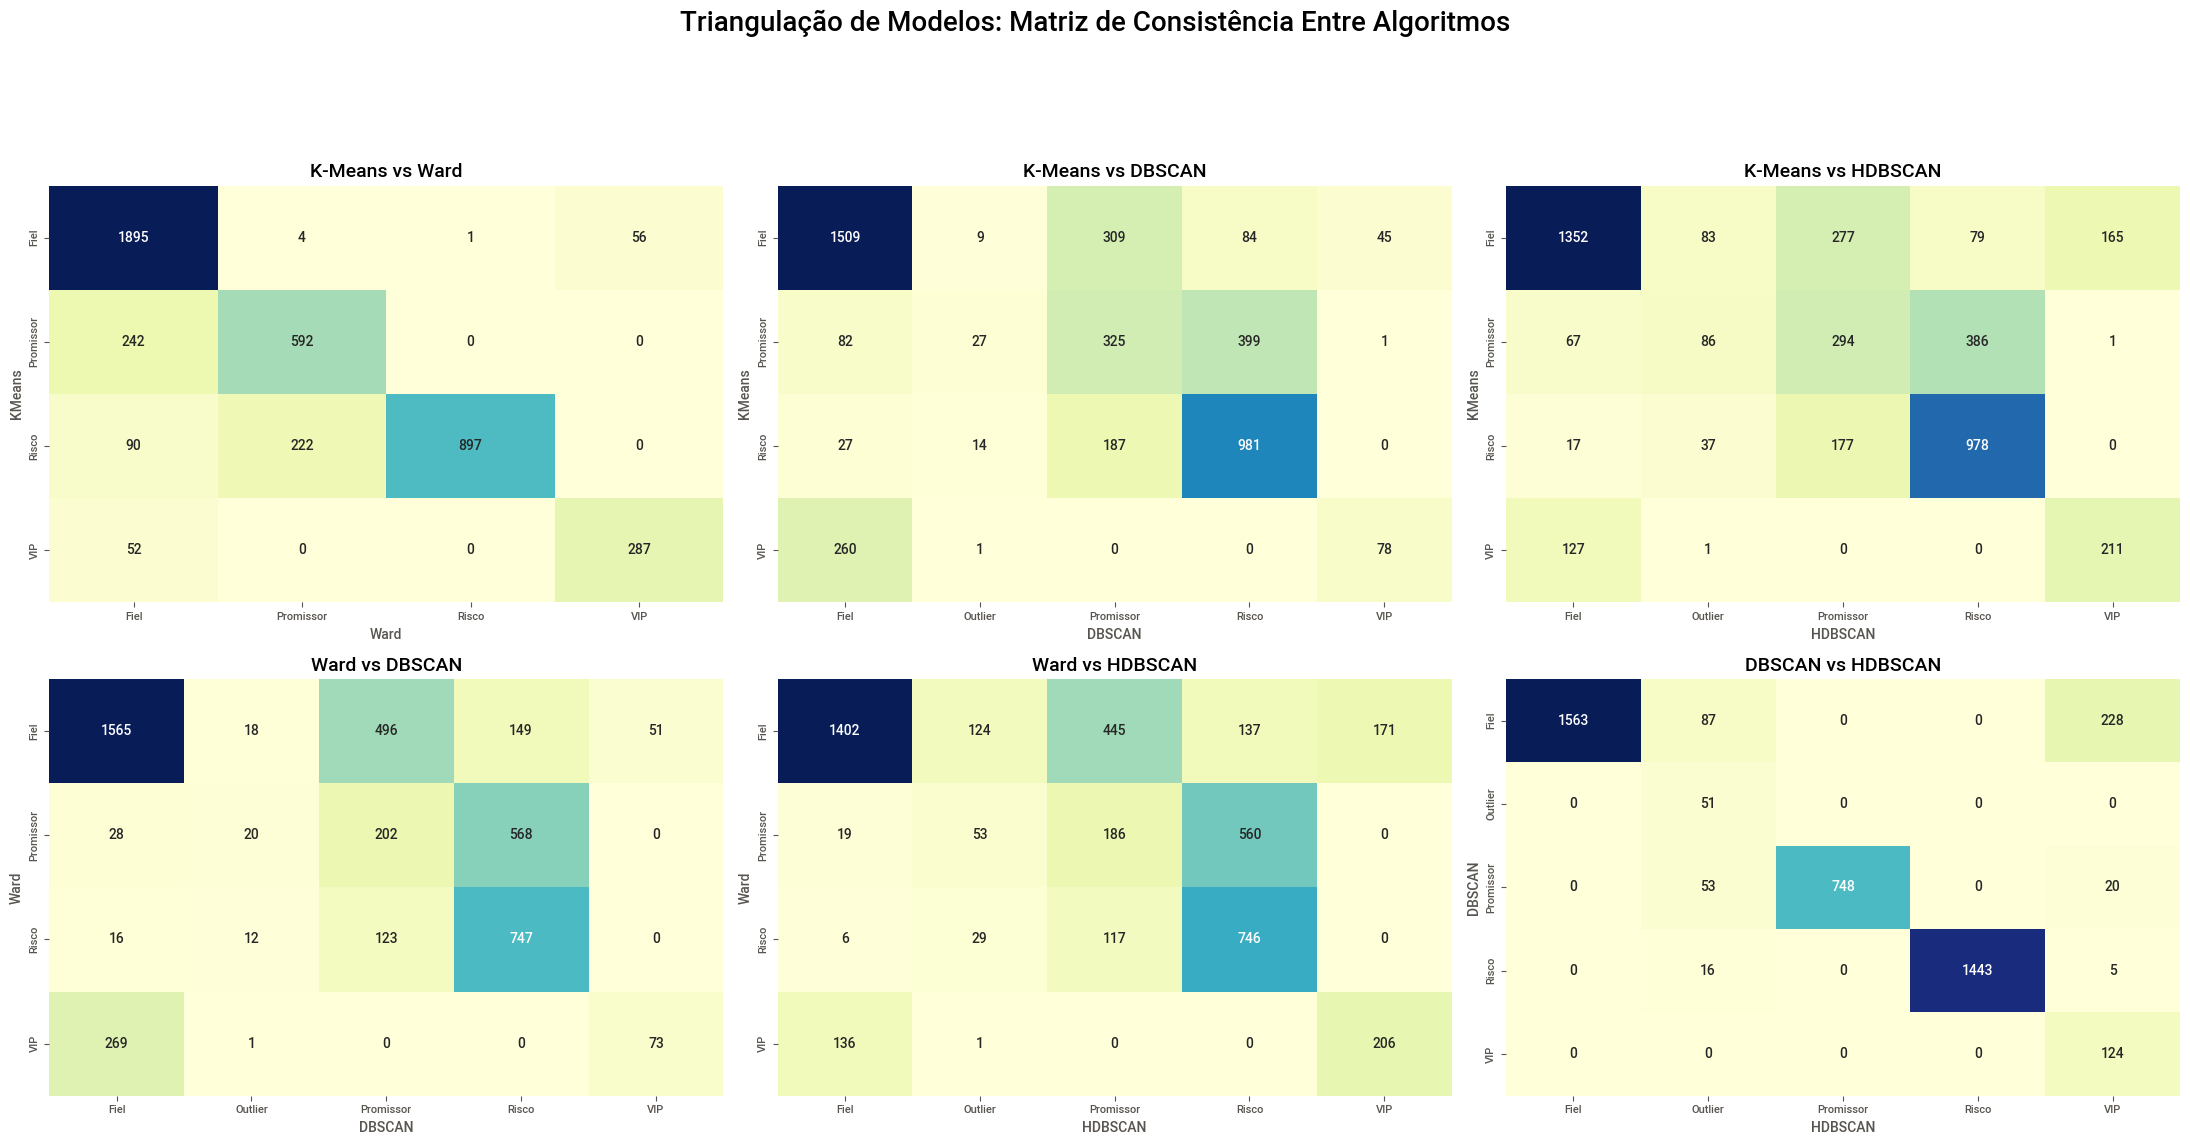

In [39]:
# 1. Definimos os pares de comparação
comparacoes = [
    ('Segmento_KMeans', 'Segmento_Ward', 'K-Means vs Ward'),
    ('Segmento_KMeans', 'Segmento_DBSCAN', 'K-Means vs DBSCAN'),
    ('Segmento_KMeans', 'Segmento_HDBSCAN', 'K-Means vs HDBSCAN'),
    ('Segmento_Ward', 'Segmento_DBSCAN', 'Ward vs DBSCAN'),
    ('Segmento_Ward', 'Segmento_HDBSCAN', 'Ward vs HDBSCAN'),
    ('Segmento_DBSCAN', 'Segmento_HDBSCAN', 'DBSCAN vs HDBSCAN')
]

# 2. Criamos a moldura (2 linhas, 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Triangulação de Modelos: Matriz de Consistência Entre Algoritmos', fontsize=20)

# O segredo está no .flatten() aqui embaixo:
for i, (col_y, col_x, titulo) in enumerate(comparacoes):
    ax = axes.flatten()[i] # Achata a matriz 2x3 em uma lista de 6 posições
    
    # Criando a tabela de cruzamento
    tabela_cruzada = pd.crosstab(df_rfm_final[col_y], df_rfm_final[col_x])
    
    # Plotando o Heatmap
    sns.heatmap(tabela_cruzada, annot=True, fmt='d', cmap='YlGnBu', ax=ax, cbar=False)
    
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xlabel(col_x.split('_')[-1])
    ax.set_ylabel(col_y.split('_')[-1])

# Opcional: Remover o último subplot se ele ficar vazio (já que você tem 5 comparações para 6 espaços)
if len(comparacoes) < 6:
    axes.flatten()[-1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.90])
plt.show()

In [40]:
# --- Similaridade entre partições (Adjusted Rand Index, ARI) ---
# ARI = 1.0 partição idêntica; ~0 aleatório; negativo pior que acaso.
rotulos = {
    "K-Means": df_rfm_final["Segmento_KMeans"],
    "DBSCAN": df_rfm_final["Segmento_DBSCAN"],
    "HDBSCAN": df_rfm_final["Segmento_HDBSCAN"],
    "Ward": df_rfm_final["Segmento_Ward"]
}
nomes = list(rotulos.keys())
ari = pd.DataFrame(np.eye(len(nomes)), index=nomes, columns=nomes)
for i, a in enumerate(nomes):
    for j, b in enumerate(nomes):
        if j <= i:
            continue
        v = adjusted_rand_score(
            pd.Categorical(rotulos[a]).codes,
            pd.Categorical(rotulos[b]).codes,
        )
        ari.loc[a, b] = ari.loc[b, a] = v
print("Matriz ARI (simetrizada) entre métodos:")
display(ari.round(3))


Matriz ARI (simetrizada) entre métodos:


,K-Means,DBSCAN,HDBSCAN,Ward
K-Means,1.000,0.399,0.386,0.648
DBSCAN,0.399,1.000,0.839,0.337
HDBSCAN,0.386,0.839,1.000,0.317
Ward,0.648,0.337,0.317,1.000


In [41]:
sil_ward = silhouette_score(X_all, df_rfm_final['Segmento_Ward'])
sil_kmeans = silhouette_score(X_all, df_rfm_final['Segmento_KMeans'])
sil_dbscan = silhouette_score(X_all[df_rfm_final['Segmento_DBSCAN'] != 'Outlier'], df_rfm_final[df_rfm_final['Segmento_DBSCAN'] != 'Outlier']['Segmento_DBSCAN'])
sil_hdbscan = silhouette_score(X_all[df_rfm_final['Segmento_HDBSCAN'] != 'Outlier'], df_rfm_final[df_rfm_final['Segmento_HDBSCAN'] != 'Outlier']['Segmento_HDBSCAN'])

print(f"Silhueta Ward: {sil_ward:.4f}")
print(f"Silhueta K-Means: {sil_kmeans:.4f}")
print(f"Silhueta DBSCAN (sem outliers): {sil_dbscan:.4f}")
print(f"Silhueta HDBSCAN (sem outliers): {sil_hdbscan:.4f}")

Silhueta Ward: 0.2331
Silhueta K-Means: 0.2791
Silhueta DBSCAN (sem outliers): 0.1485
Silhueta HDBSCAN (sem outliers): 0.1483


In [42]:
# Distribuição de clientes por método (contagens por segmento)
resumo_dist1 = pd.DataFrame({
    'K-Means': df_rfm_final['Segmento_KMeans'].value_counts(),
    'DBSCAN': df_rfm_final['Segmento_DBSCAN'].value_counts(),
    'HDBSCAN': df_rfm_final['Segmento_HDBSCAN'].value_counts(),
    'Ward': df_rfm_final['Segmento_Ward'].value_counts()
}).fillna(0).astype(int)

print("Distribuição de clientes por método:")
display(resumo_dist1)


Distribuição de clientes por método:


,K-Means,DBSCAN,HDBSCAN,Ward
Fiel,1956,1878,1563,2279
Outlier,0,51,207,0
Promissor,834,821,748,818
Risco,1209,1464,1443,898
VIP,339,124,377,343
